## Sentiment shifts

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#df = pd.read_csv("../Sample/Datasets/Sample_master.tsv", sep="\t", encoding="utf-8") #--> Sample dataset input
df = pd.read_csv("../ParlaMint-SI_full_dataset.tsv", sep="\t", encoding="utf-8") #--> Full dataset input

print("Full dataset shape:", df.shape)
df = df[df["Speaker_role"] != "Chairperson"]#Remove chairperson speakers to not include procedural speeches
df = df[df["Speaker_minister"] == "notMinister"]#Remove chairperson speakers to not include procedural speeches

print("Dataset shape:", df.shape)

df.head()


Full dataset shape: (311354, 30)
Dataset shape: (138219, 30)


,ID,Text,Date,Term,Meeting,Subcorpus,Speaker_role,Speaker_MP,Speaker_minister,Speaker_party,...,Senti_n,Sents,Words,Tokens,Parties,Year,party_id,lrgen,galtan,Seat
1,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u2,Hvala lepa za besedo. Spoštovana predsednica V...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,SLS,...,0.33,19,284,327,SLS+SKD/SLS,2013,NaN,NaN,NaN,NaN
3,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u4,"Spoštovane poslanke in poslanci, lep pozdrav p...",2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,-,...,3.51,29,562,662,-,2013,NaN,NaN,NaN,NaN
5,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u6,Hvala lepa še enkrat za besedo. Spoštovana pre...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,SLS,...,0.16,14,227,266,SLS+SKD/SLS,2013,NaN,NaN,NaN,NaN
7,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u8,Najlepša hvala. Spoštovani poslanec! Jaz misli...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,-,...,2.72,18,226,269,-,2013,NaN,NaN,NaN,NaN
9,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u10,Res je. Hvala še enkrat za besedo. Na podlagi ...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,SLS,...,1.28,7,111,130,SLS+SKD/SLS,2013,NaN,NaN,NaN,NaN


## Party status sentiment shifts

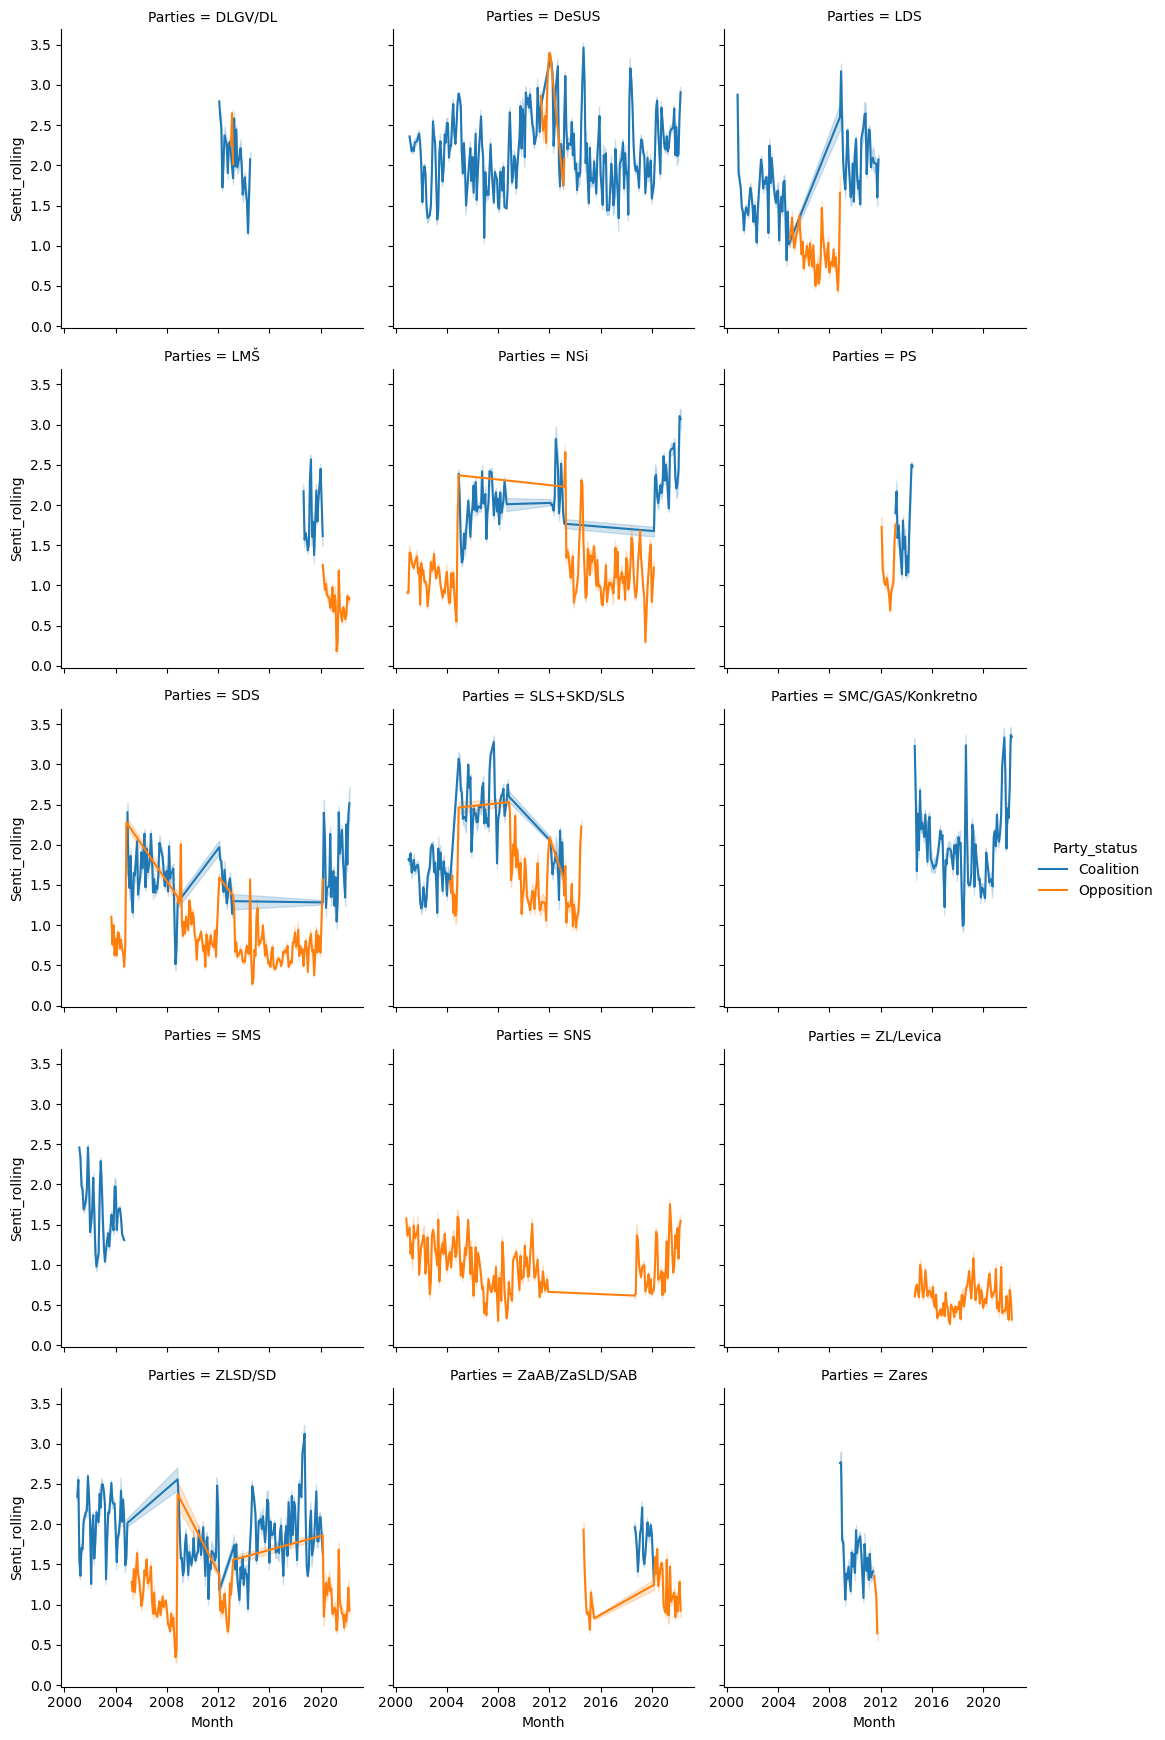

In [3]:
cols = ["IMNS", "-", "NeP", "NP", "Lipa", "DLGV"]
status = df[~df.isin(cols)]
status["Date"] = pd.to_datetime(status["Date"])
status["Year"] = pd.to_datetime(status["Year"])
status["Month"] = status["Date"].dt.to_period("M").dt.to_timestamp()
status = status.sort_values(['Parties', 'Date'])

# Change rolling sentiment parameter for different visualisations.
# Sample rolling sentiment: rolling(30)
# Full dataset rolling sentiment: rolling(65)

# Compute rolling mean sentiment over last 30 speeches per party
status['Senti_rolling'] = status.groupby('Parties')['Senti_n'].transform(
    lambda x: x.rolling(30).mean()
)

sns.relplot(
    data=status, x="Month", y='Senti_rolling', hue='Party_status',
    kind='line', col='Parties', col_wrap=3, height=3.5
)
plt.show()

Party status sentiment shifts:
The plot visualizes relationship between sentiment for individual party per their political status. The rolling sentiment is calculated based on the 30 speeches per party/status subset to smooth the sharp changes in sentiment. 
Trends: 
- The sentiment changes occur when party/group changes their status in the Parliament. The clearest examples of this can be seen for SDS and ZLSD/SD. 
- The sentiment drops when party changes their status from Coalition to Opposition

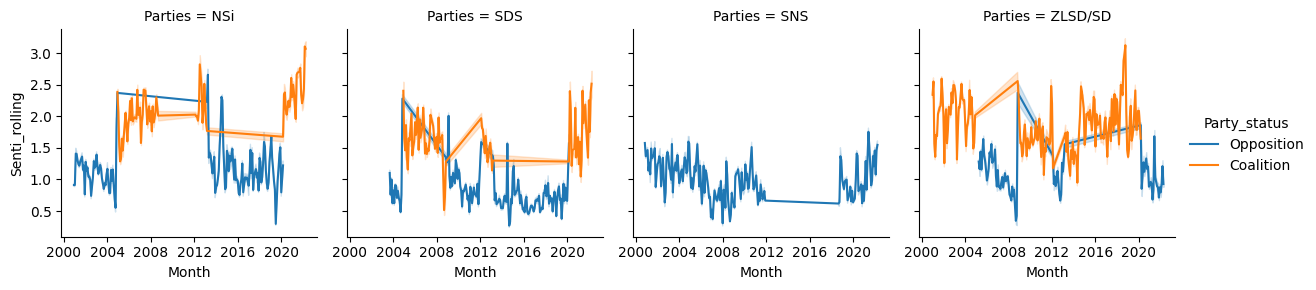

In [4]:
cols = ["SDS", "ZLSD/SD", "NSi", "SNS"]
selection = status[status["Parties"].isin(cols)].copy()


selection['Senti_rolling'] = status.groupby('Parties')['Senti_n'].transform(
    lambda x: x.rolling(30).mean()
)

sns.relplot(
    data=selection, x="Month", y='Senti_rolling', hue='Party_status',
    kind='line', col='Parties', col_wrap=4, height=3
)
plt.show()

Selection of the Parties with the more interesting patterns (Chapter)

In [5]:
# Change rolling sentiment parameter for different visualisations.
# Sample rolling sentiment: rolling(1)
# Full dataset rolling sentiment: rolling(20)
status["Year"] = status["Year"].astype(int)

gov_changes = [
    ("2000-11-30", "6. Gov (Drnovšek)"),
    ("2002-12-19", "7. Gov (Rop)"),
    ("2004-12-03", "8. Gov (Janša)"),
    ("2008-11-21", "9. Gov (Pahor)"), 
    ("2012-02-10", '10. Gov (Janša)'),
    ("2013-03-20", '11. Gov (Bratušek)'), 
    ("2014-09-18", '12. Gov (Cerar)'),
    ("2018-09-13", '13. Gov (Šarec)'),
    ('2020-03-13', '14. Gov (Janša)'),
    
]
trend_blocs = (
    status.groupby([status["Date"].dt.to_period("M"),'Parties'])['Senti_n']
      .mean().unstack().rolling(20).mean()
)

trend_blocs

Parties,DLGV/DL,DeSUS,LDS,LMŠ,NSi,PS,SDS,SLS+SKD/SLS,SMC/GAS/Konkretno,SMS,SNS,ZL/Levica,ZLSD/SD,ZaAB/ZaSLD/SAB,Zares
Date,,,,,,,,,,,,,,,
2000-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12,NaN,2.377089,NaN,0.776160,2.334891,NaN,1.675075,NaN,2.169331,NaN,1.125013,0.591636,1.042293,1.160790,NaN
2022-01,NaN,2.361318,NaN,0.762347,2.360358,NaN,1.711824,NaN,2.220948,NaN,1.120472,0.573091,1.010647,1.160048,NaN
2022-02,NaN,2.359041,NaN,0.741399,2.352040,NaN,1.662624,NaN,2.279031,NaN,1.116820,0.589933,1.017205,1.130131,NaN


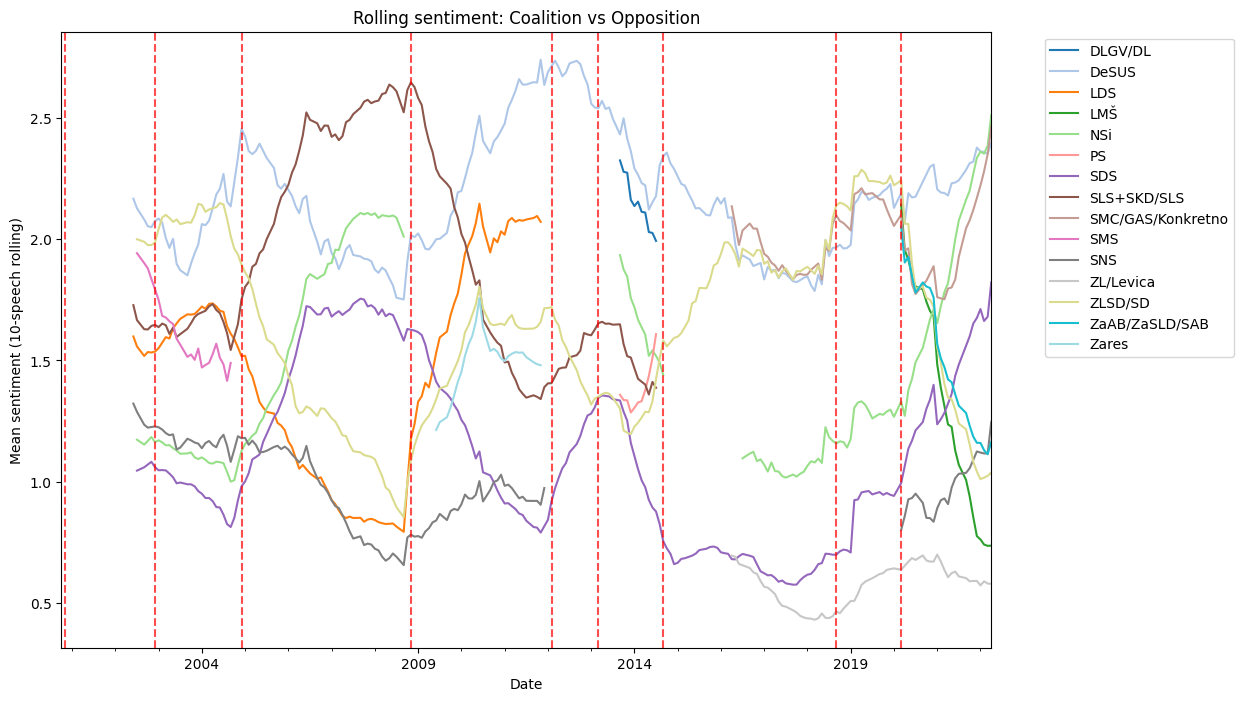

In [6]:
trend_blocs.plot(figsize=(12,8), cmap="tab20")
for date, label in gov_changes:
    plt.axvline(pd.Timestamp(date), color='red', linestyle='--', alpha=0.7)
plt.title("Rolling sentiment: Coalition vs Opposition")
plt.ylabel("Mean sentiment (10-speech rolling)")
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.show()

Rolling sentiment - Coalition vs. Opposition
The plot presents the rolling average sentiment calculated for individual party per month to showcase the trends in sentiment changes throughout the period. The vertical lines represent changes in government, and therefore, switches between coalition and opposition parties (or, rather, their status, if it occurs).

2004 (8th Government - Janša):
- SDS, NSi, SLS+SKD/SLS shot up in their sentiment
- SMS is left out
- ZLSD/SD, LDS, SNS sentiment goes down.

2008 (9th Government - Pahor):
- LDS, DeSUS , ZLSD/SD- sentiment goes up,
- NSi is left out
- SLS+SKD/SLS, SDS - Sentiment goes down, SNS sentiment goes up slightly (SNS is always in opposition throughout the period)

2012 (10th Government - Janša):
- SNS, LDS is left out
- DeSUS (slightly), ZLSD/SD, - sentiment goes down,
- SLS+SKS/SLS (SLS), SDS - sentiment goes up

2013 (11th Government - Bratušek):
- SDS, SLS, DeSUS - sentiment goes down, 
- ZLSD/SD (SD) sentiment goes slightly down but picks up again in the middle of the Year
- NSi, DLGV/DL, PS (re)join Parliament, sentiment is on the downward trend for NSi and DLGV/DL, PS sentiment on upward trend

2014 (12th Government - Cerar):
- SDS, DeSUS, SMC (new), NSi - sentiment is on a downward trend, 
- SD - sentiment up, 
- Levica, ZaAB elected into Parliament, lower(est) sentiment trend

2018 (13th Government - Šarec):
- Short period, will be further evaluated for closer changes in Sentiment within Term-based trends

2020 (14th Government - Janša):
- LMŠ, ZLSD/SD, SAB, Levica down, 
- SNS, SDS, NSi, DeSUS up



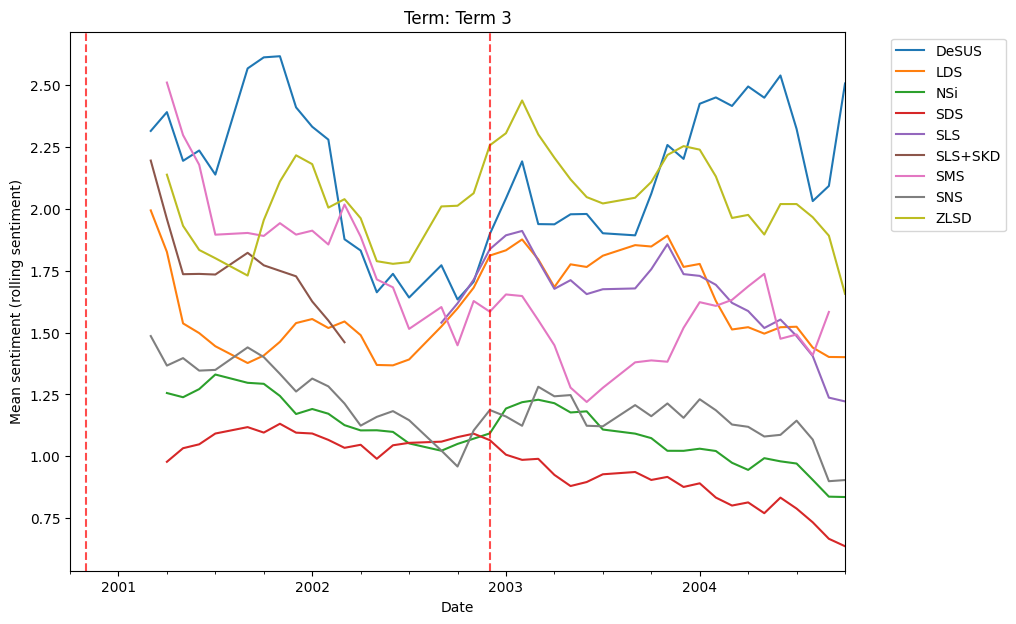

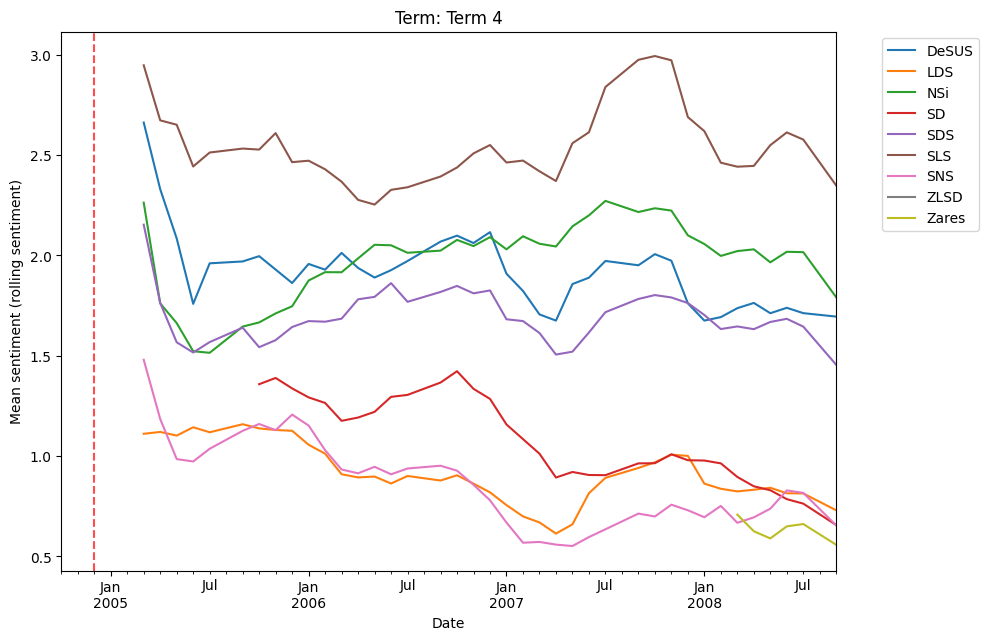

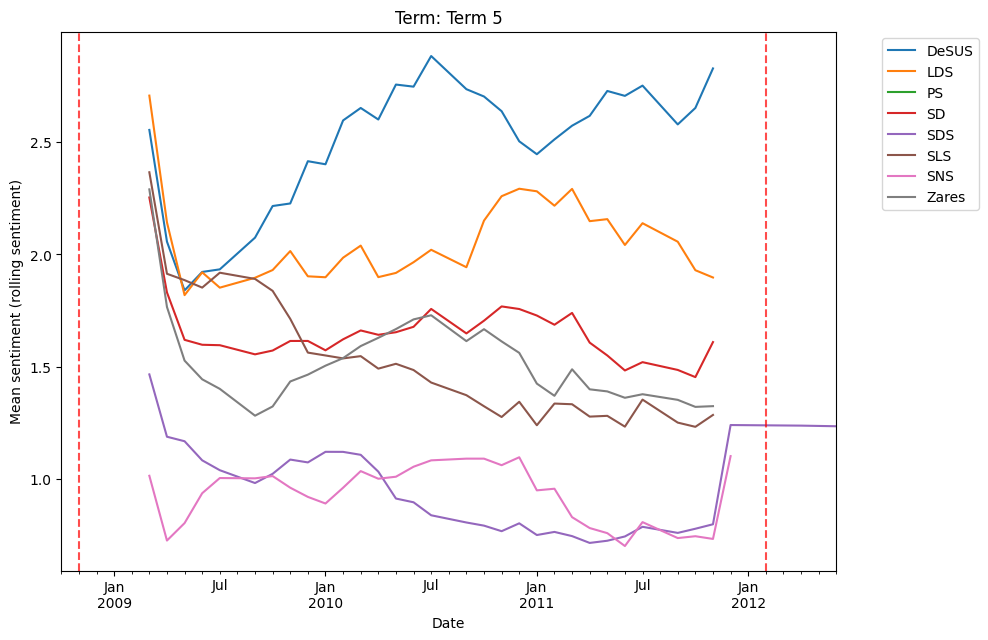

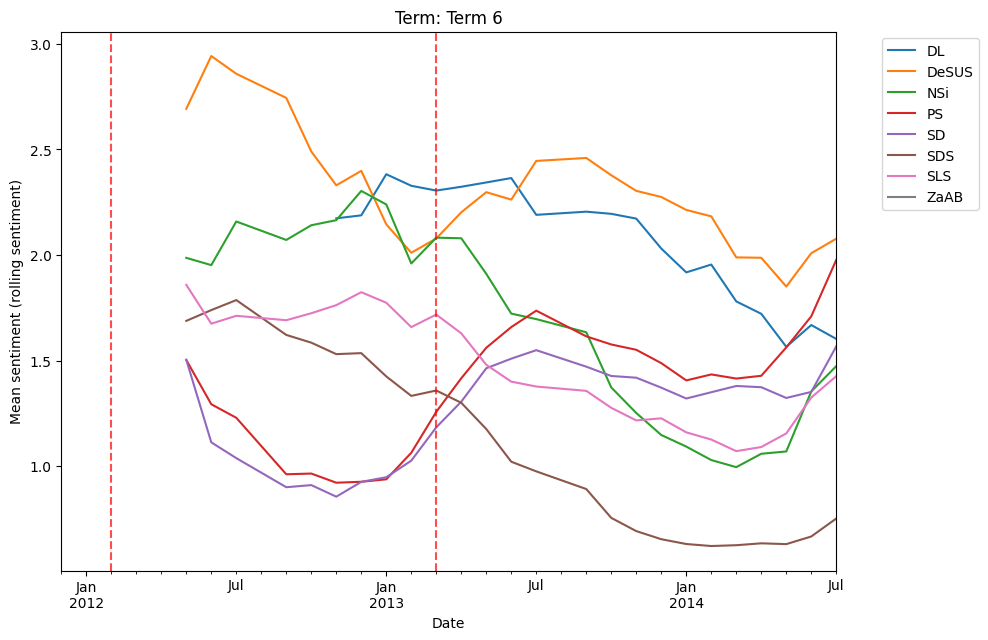

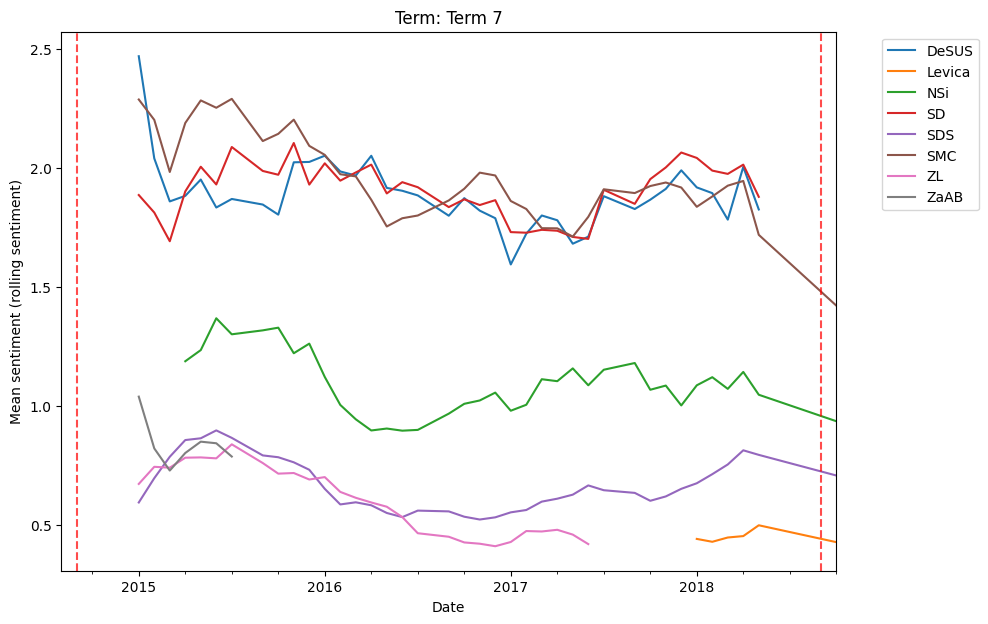

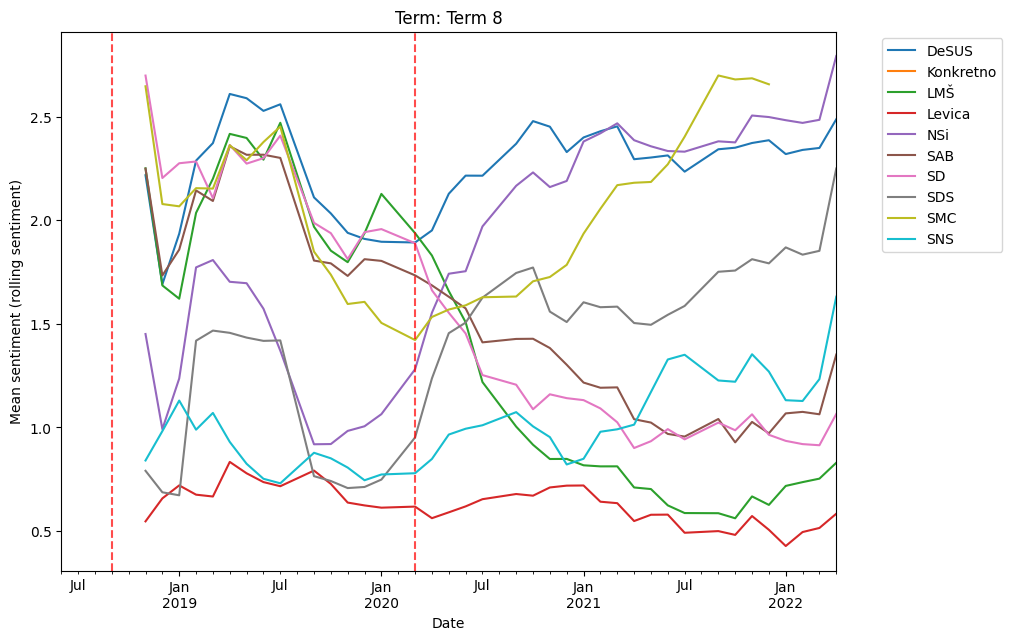

In [7]:
# Individual Term plots (with all government changes in each Term)
# Sample rolling sentiment: rolling(1)
# Full dataset rolling sentiment: rolling(5)

for term, sub in status.groupby('Term'):
    trend = sub.groupby([status["Date"].dt.to_period("M"),'Speaker_party'])['Senti_n'].mean().unstack().rolling(6).mean()
    trend.plot(figsize=(10,7), title=f"Term: {term}")
    plt.ylabel("Mean sentiment (rolling sentiment)")
    for date, label in gov_changes:
        if sub['Date'].min() <= pd.Timestamp(date) <= sub['Date'].max():
            plt.axvline(pd.Timestamp(date), color='red', linestyle='--', alpha=0.7)
        plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.show()

Individual Term plot - Rolling sentiment by Party (Month)

Term 3:
- Due to rolling sentiment direct changes in Gov 6 are not possible
- Gov 7 changes (2002-12-19, 7. Gov (Rop)):
    - ZLSD, DeSUS, SMS, LDS, SLS: sentiment rising (from opposition to coalition)
    - SDS, NSi, SNS (slightly): sentiment dropping (going from opposition to coalition)

Term 4:
- 2004-12-03, 8. Gov (Janša), Clearer division in senitment: 
    - SLS, DeSUS, NSi, SDS: sentiment rising (going from opposition to coalition)
    - SD, LDS, SNS: sentiment dropping (lower in the entire term): going from coalition to opposition

Term 5: (2008-11-21, 9. Gov (Pahor): Not so clear distinctions between the party sentiment
- Higher in sentiment: DeSUS, LDS, SD, Zares (coalition)
- Lower in sentiment: SDS, SNS, SLS (drop later in the Gov term), (opposition)

Term 6: (2012-02-10, 10. Gov (Janša):
- DeSUS, NSi, SLS, SDS -> Higher in sentiment (coalition)
- PS, SD -> Lower in sentiment, (opposition)

- (2013-03-20", '11. Gov (Bratušek)'):
    - PS, SD -> Sentiment rising, going from opposition to coaliton
    - SDS, DeSUS, NSi, SLS -> sentiment dropping, coalition to opposition 

Term 7:
-  (2014-09-18", '12. Gov (Cerar)'),
    - Clear distinction in sentiment between coal and oppo parties:
    - SMC, SD, DeSUS - higher in sentiment (in coalition)
    - SDS, NSi, ZL, ZaAB - lower in sentiment (in opposition)

Term 8
-  ("2018-09-13", '13. Gov (Šarec)')
    - LMŠ, SMC, SD, SAB, DeSUS - Higher in sentiment (coalition)
        - Levica, NSi, SDS, SNS - dropping in sentiment (opposition)
-   '2020-03-13', '14. Gov (Janša)',
    - SDS, NSi, SMC, DeSUS - rising in sentiment (coalition)
    - SAB, Levica, SD, LMŠ, SNS (though Levica is really low in sentiment at any given po)




In [8]:
gov_changes = [(pd.Timestamp(d), name) for d, name in gov_changes]
gov_changes

[(Timestamp('2000-11-30 00:00:00'), '6. Gov (Drnovšek)'),
 (Timestamp('2002-12-19 00:00:00'), '7. Gov (Rop)'),
 (Timestamp('2004-12-03 00:00:00'), '8. Gov (Janša)'),
 (Timestamp('2008-11-21 00:00:00'), '9. Gov (Pahor)'),
 (Timestamp('2012-02-10 00:00:00'), '10. Gov (Janša)'),
 (Timestamp('2013-03-20 00:00:00'), '11. Gov (Bratušek)'),
 (Timestamp('2014-09-18 00:00:00'), '12. Gov (Cerar)'),
 (Timestamp('2018-09-13 00:00:00'), '13. Gov (Šarec)'),
 (Timestamp('2020-03-13 00:00:00'), '14. Gov (Janša)')]

In [9]:
term_sent = df.groupby(['Term', 'Year', 'Speaker_party']).agg({'Senti_n':'mean'}).reset_index()
term_sent = term_sent.sort_values(by='Year', ascending=True)

In [10]:
from pandas.api.types import CategoricalDtype

sentiment_shifts = []

for i, (change_date, gov_name) in enumerate(gov_changes):
    prev_date = gov_changes[i-1][0] if i > 0 else status['Date'].min()
    next_date = gov_changes[i+1][0] if i+1 < len(gov_changes) else df['Date'].max()
    
    # Define period window (one year before/after for example)
    before = status[(status['Date'] >= prev_date) & (status['Date'] < change_date)]
    after  = status[(status['Date'] >= change_date) & (status['Date'] < next_date)]
    
    # Compute mean sentiment by party or bloc
    before_mean = before.groupby('Speaker_party')['Senti_n'].mean().rename('Before')
    after_mean  = after.groupby('Speaker_party')['Senti_n'].mean().rename('After')
    
    merged = pd.concat([before_mean, after_mean], axis=1)
    merged['Change'] = merged['After'] - merged['Before']
    merged['Gov_change'] = gov_name
    sentiment_shifts.append(merged.reset_index())

sentiment_shift_df = pd.concat(sentiment_shifts, ignore_index=True)
sentiment_shift_df

gov_order = CategoricalDtype(['6. Gov (Drnovšek)', '7. Gov (Rop)', '8. Gov (Janša)', '9. Gov (Pahor)', '10. Gov (Janša)', '11. Gov (Bratušek)', '12. Gov (Cerar)', '13. Gov (Šarec)', '14. Gov (Janša)'], ordered=True)
sentiment_shift_df['Gov_change'] = sentiment_shift_df['Gov_change'].astype(gov_order)

sentiment_shift_df


,Speaker_party,Before,After,Change,Gov_change
0,DeSUS,3.203333,2.056689,-1.146645,6. Gov (Drnovšek)
1,LDS,2.901000,1.485482,-1.415518,6. Gov (Drnovšek)
2,SLS+SKD,2.702222,1.592925,-1.109297,6. Gov (Drnovšek)
3,SMS,2.552000,1.845142,-0.706858,6. Gov (Drnovšek)
4,SNS,1.899500,1.228605,-0.670895,6. Gov (Drnovšek)
...,...,...,...,...,...
88,SD,1.844199,1.018804,-0.825395,14. Gov (Janša)
89,SDS,0.747137,1.689168,0.942030,14. Gov (Janša)
90,SMC,1.638247,2.080694,0.442447,14. Gov (Janša)
91,SNS,0.907553,1.167805,0.260252,14. Gov (Janša)


In [11]:
sentiment_shift_df[sentiment_shift_df["Speaker_party"] == "SDS"]

,Speaker_party,Before,After,Change,Gov_change
7,SDS,NaN,1.062267,NaN,6. Gov (Drnovšek)
12,SDS,1.062267,0.860522,-0.201745,7. Gov (Rop)
21,SDS,0.860522,1.664367,0.803846,8. Gov (Janša)
32,SDS,1.664367,0.934921,-0.729447,9. Gov (Pahor)
43,SDS,0.934921,1.505262,0.570341,10. Gov (Janša)
53,SDS,1.505262,0.683672,-0.821590,11. Gov (Bratušek)
63,SDS,0.683672,0.668611,-0.015061,12. Gov (Cerar)
78,SDS,0.668611,0.747137,0.078526,13. Gov (Šarec)
89,SDS,0.747137,1.689168,0.942030,14. Gov (Janša)


In [12]:
sentiment_shift_df.pivot_table(
    index='Speaker_party', columns='Gov_change', values='Change', observed=True
).round(2)

Gov_change,6. Gov (Drnovšek),7. Gov (Rop),8. Gov (Janša),9. Gov (Pahor),10. Gov (Janša),11. Gov (Bratušek),12. Gov (Cerar),13. Gov (Šarec),14. Gov (Janša)
Speaker_party,,,,,,,,,
DL,NaN,NaN,NaN,NaN,NaN,-0.35,NaN,NaN,NaN
DeSUS,-1.15,0.24,-0.43,0.60,-0.17,-0.06,-0.31,0.03,0.46
LDS,-1.42,0.09,-0.65,1.09,NaN,NaN,NaN,NaN,NaN
LMŠ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.35,-1.04
Levica,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.24,-0.11
NSi,NaN,-0.15,0.93,0.06,0.19,-0.89,-0.23,0.04,1.31
PS,NaN,NaN,NaN,NaN,-0.77,0.57,NaN,NaN,NaN
SAB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.37,-0.53
SD,NaN,NaN,NaN,0.55,-0.64,0.41,0.54,-0.10,-0.83


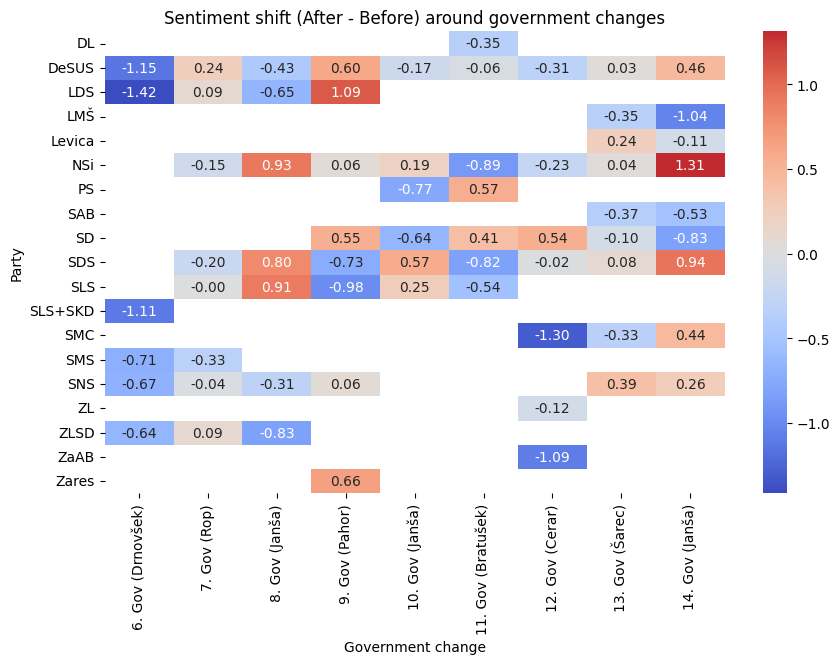

In [13]:
import seaborn as sns
plt.figure(figsize=(10,6))


sns.heatmap(
    sentiment_shift_df.pivot_table(
        index='Speaker_party', columns='Gov_change', observed=True, values='Change',
    ),
    cmap='coolwarm', center=0, annot=True, fmt=".2f"
)
plt.title('Sentiment shift (After - Before) around government changes')
plt.ylabel('Party')
plt.xlabel('Government change')
plt.show()

Sentiment shift changes (heatmap)
Comparing the changes in sentiment between parties and changes in Government.
- The highest changes recorded are the NSi move from 13th to 14th Government (Šarec to Janša) with a positive jump in sentiment (1.31), while the highest decrease in sentiment belongs to LDS in the 6th Government with -1.42, followed by SMC in a change from Gov 11 to Gov 12 (Bratušek to Cerar, -1.30).
- DeSUS is realtively stable in their sentiment throughout the Government changes with slight changes in sentiment.
- The overall changes are not too drastic, which is understadable, considering the overall low sentiment (i.e. mean sentiment score is 1.3, while the median is 0.66). Additonally, when plotting sentiment trends for individual parties per Party status, Party orientation etc, the highest average barely reached sentiment of around 2.5-3.


In [14]:
## Political orientation sentiment shifts
#sns.relplot(
#    data=df, x='Date', y='Senti_rolling', hue='Party_orientation',
#    kind='line', col='Speaker_party', col_wrap=3, height=4
#)
#plt.show()

## Political orientation sentiment shifts

In [15]:
df.head()


,ID,Text,Date,Term,Meeting,Subcorpus,Speaker_role,Speaker_MP,Speaker_minister,Speaker_party,...,Senti_n,Sents,Words,Tokens,Parties,Year,party_id,lrgen,galtan,Seat
1,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u2,Hvala lepa za besedo. Spoštovana predsednica V...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,SLS,...,0.33,19,284,327,SLS+SKD/SLS,2013,NaN,NaN,NaN,NaN
3,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u4,"Spoštovane poslanke in poslanci, lep pozdrav p...",2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,-,...,3.51,29,562,662,-,2013,NaN,NaN,NaN,NaN
5,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u6,Hvala lepa še enkrat za besedo. Spoštovana pre...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,SLS,...,0.16,14,227,266,SLS+SKD/SLS,2013,NaN,NaN,NaN,NaN
7,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u8,Najlepša hvala. Spoštovani poslanec! Jaz misli...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,-,...,2.72,18,226,269,-,2013,NaN,NaN,NaN,NaN
9,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u10,Res je. Hvala še enkrat za besedo. Na podlagi ...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,SLS,...,1.28,7,111,130,SLS+SKD/SLS,2013,NaN,NaN,NaN,NaN


In [16]:
check = df[["Year", "Speaker_party", "Parties", "lrgen", "galtan"]].drop_duplicates().sort_values(by="Year").reset_index(drop=True)

#check.to_csv("LRGEN-GALTAN_check.csv") #Sanity check of the initial lrgen/galtan values before interpolation procedure
check

,Year,Speaker_party,Parties,lrgen,galtan
0,2000,LDS,LDS,NaN,NaN
1,2000,NSi,NSi,NaN,NaN
2,2000,-,-,NaN,NaN
3,2000,SDS,SDS,NaN,NaN
4,2000,DeSUS,DeSUS,NaN,NaN
...,...,...,...,...,...
254,2022,SNS,SNS,NaN,NaN
255,2022,Konkretno,SMC/GAS/Konkretno,NaN,NaN
256,2022,IMNS,IMNS,NaN,NaN
257,2022,-,-,NaN,NaN


In [17]:
party_interp = (df.groupby(["Speaker_party", "Year"], as_index=False)[["lrgen", "galtan"]].mean().sort_values(["Speaker_party", "Year"]))
party_interp.head()

,Speaker_party,Year,lrgen,galtan
0,-,2000,NaN,NaN
1,-,2001,NaN,NaN
2,-,2002,NaN,NaN
3,-,2003,NaN,NaN
4,-,2004,NaN,NaN


### Interpolating the CHES values for sentiment switch trends
Given the relatively scares points from the CHES dataset, we decided to interpolate the values for individual years. As we do not want to predic the values for years at both ends of the spectrum (e.g. 2000-2002; 2020-2022), we limit the interpolation method with "both" parameter (values on both ends assume the value of the last Year in CHES dataset (2002 and 2019 respectively))

In [18]:
party_interp[["lrgen", "galtan"]] = (party_interp.groupby("Speaker_party")[["lrgen", "galtan"]].apply(lambda x: x.interpolate(limit_direction="both")).reset_index(drop=True))
party_interp["lrgen"] = party_interp["lrgen"].apply(lambda x: f"{x:.2f}")
party_interp["galtan"] = party_interp["galtan"].apply(lambda x: f"{x:.2f}")

#party_interp.to_csv("LRGEN-GALTAN-sanity-check.csv") #Manual check if interpolation makes sense

In [19]:
df = df.drop(columns=["lrgen", "galtan"]).merge(party_interp, on=["Speaker_party", "Year"], how="left")
df.head()
#df.to_csv("../Sample/Datasets/Sample_interpolated_values.tsv", sep="\t",  encoding='utf-8', index=False) #--> Save full dataset
#df.to_csv("../Results/Datasets/ParlaMint_CHES_interpolated_values.tsv", sep="\t",  encoding='utf-8', index=False) --> Save full dataset


,ID,Text,Date,Term,Meeting,Subcorpus,Speaker_role,Speaker_MP,Speaker_minister,Speaker_party,...,Senti_n,Sents,Words,Tokens,Parties,Year,party_id,Seat,lrgen,galtan
0,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u2,Hvala lepa za besedo. Spoštovana predsednica V...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,SLS,...,0.33,19,284,327,SLS+SKD/SLS,2013,NaN,NaN,6.49,7.21
1,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u4,"Spoštovane poslanke in poslanci, lep pozdrav p...",2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,-,...,3.51,29,562,662,-,2013,NaN,NaN,nan,nan
2,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u6,Hvala lepa še enkrat za besedo. Spoštovana pre...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,SLS,...,0.16,14,227,266,SLS+SKD/SLS,2013,NaN,NaN,6.49,7.21
3,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u8,Najlepša hvala. Spoštovani poslanec! Jaz misli...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,-,...,2.72,18,226,269,-,2013,NaN,NaN,nan,nan
4,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u10,Res je. Hvala še enkrat za besedo. Na podlagi ...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,SLS,...,1.28,7,111,130,SLS+SKD/SLS,2013,NaN,NaN,6.49,7.21


### Relation between lrgen and sentiment 

In [20]:
df["lrgen"] = pd.to_numeric(df["lrgen"], errors="coerce")
df["Senti_n"] = pd.to_numeric(df["Senti_n"], errors="coerce")
df["Year"] = df["Year"].astype(int)

sent_lrgen = df.groupby(["Parties", "Party_status", "Year"]).agg(
    sentiment = ("Senti_n", "mean"),
    lrgen = ("lrgen", "mean")
).reset_index()

#cols = ["IMNS", "-", "NeP", "NP", "Lipa", "DLGV", "DL", "Konkretno"] #Speaker_party
cols = ["IMNS", "-", "NeP", "NP", "Lipa", "DLGV/DL", "Konkretno"] #Parties

sent_lrgen = sent_lrgen[~sent_lrgen.isin(cols)]
sent_lrgen.head(10)
sent_lrgen.shape

(295, 5)

In [21]:
sent_lrgen = sent_lrgen.melt(
    id_vars=["Parties", "Party_status", "Year"],
    value_vars=["sentiment", "lrgen"],
    var_name="Metric",
    value_name="Value"
)
sent_lrgen

,Parties,Party_status,Year,Metric,Value
0,NaN,NaN,2000,sentiment,2.240000
1,NaN,NaN,2001,sentiment,2.220354
2,NaN,NaN,2002,sentiment,2.060740
3,NaN,NaN,2003,sentiment,2.296387
4,NaN,NaN,2004,sentiment,2.152292
...,...,...,...,...,...
585,Zares,Coalition,2008,lrgen,3.900000
586,Zares,Coalition,2009,lrgen,3.900000
587,Zares,Coalition,2010,lrgen,3.900000
588,Zares,Coalition,2011,lrgen,3.900000


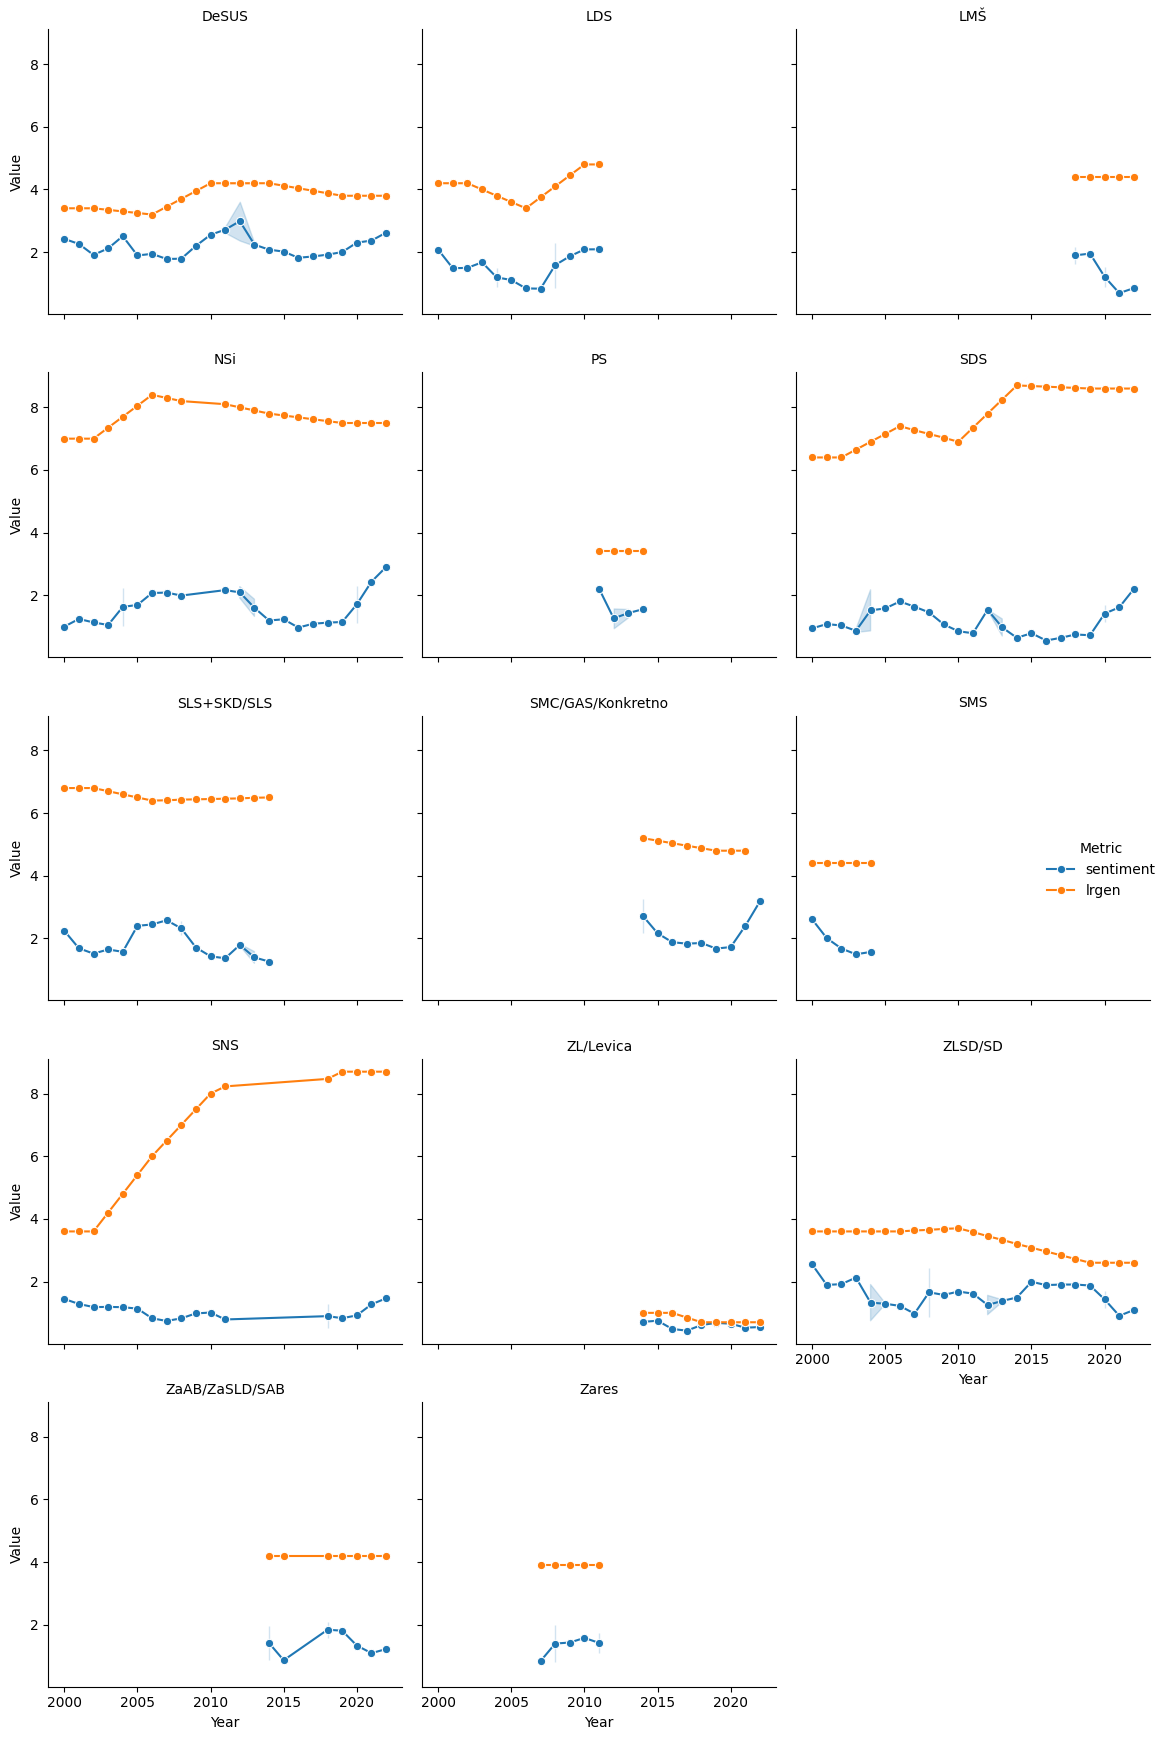

In [22]:
g = sns.FacetGrid(sent_lrgen, col="Parties", col_wrap=3, height=3.5, sharey=True, legend_out=True)
g.map_dataframe(sns.lineplot, x="Year", y="Value", hue="Metric",marker="o")

g.add_legend(title="Metric")
g.set_axis_labels("Year", "Value")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

Relationship between sentiment and LREGN:
The plot visualises relationship between averaged sentiment and LRGEN scores per Year per Party. The lines (or triangles) in sentiment trends denote changes in the party status (e.g. moving from opposition to coalition, or vice versa).The most distinct trend in most of the party trends is the distinct difference between sentiment and lrgen value, where (with exception of ZL/Levica), the sentiment is considerabley lower (and does not fluctuate distinctly with direction of the lrgen change).

### Relationship between galtan and sentiment

In [23]:
df["galtan"] = pd.to_numeric(df["galtan"], errors="coerce")

sent_galtan = df.groupby(["Parties", "Party_status", "Year"]).agg(
    sentiment = ("Senti_n", "mean"),
    galtan = ("galtan", "mean"),
).reset_index()

sent_galtan = sent_galtan[~sent_galtan.isin(cols)]

In [24]:
sent_galtan = sent_galtan.melt(
    id_vars=["Parties", "Party_status", "Year"],
    value_vars=["sentiment", "galtan"],
    var_name="Metric",
    value_name="Value"
)

sent_galtan

,Parties,Party_status,Year,Metric,Value
0,NaN,NaN,2000,sentiment,2.240000
1,NaN,NaN,2001,sentiment,2.220354
2,NaN,NaN,2002,sentiment,2.060740
3,NaN,NaN,2003,sentiment,2.296387
4,NaN,NaN,2004,sentiment,2.152292
...,...,...,...,...,...
585,Zares,Coalition,2008,galtan,1.800000
586,Zares,Coalition,2009,galtan,1.800000
587,Zares,Coalition,2010,galtan,1.800000
588,Zares,Coalition,2011,galtan,1.800000


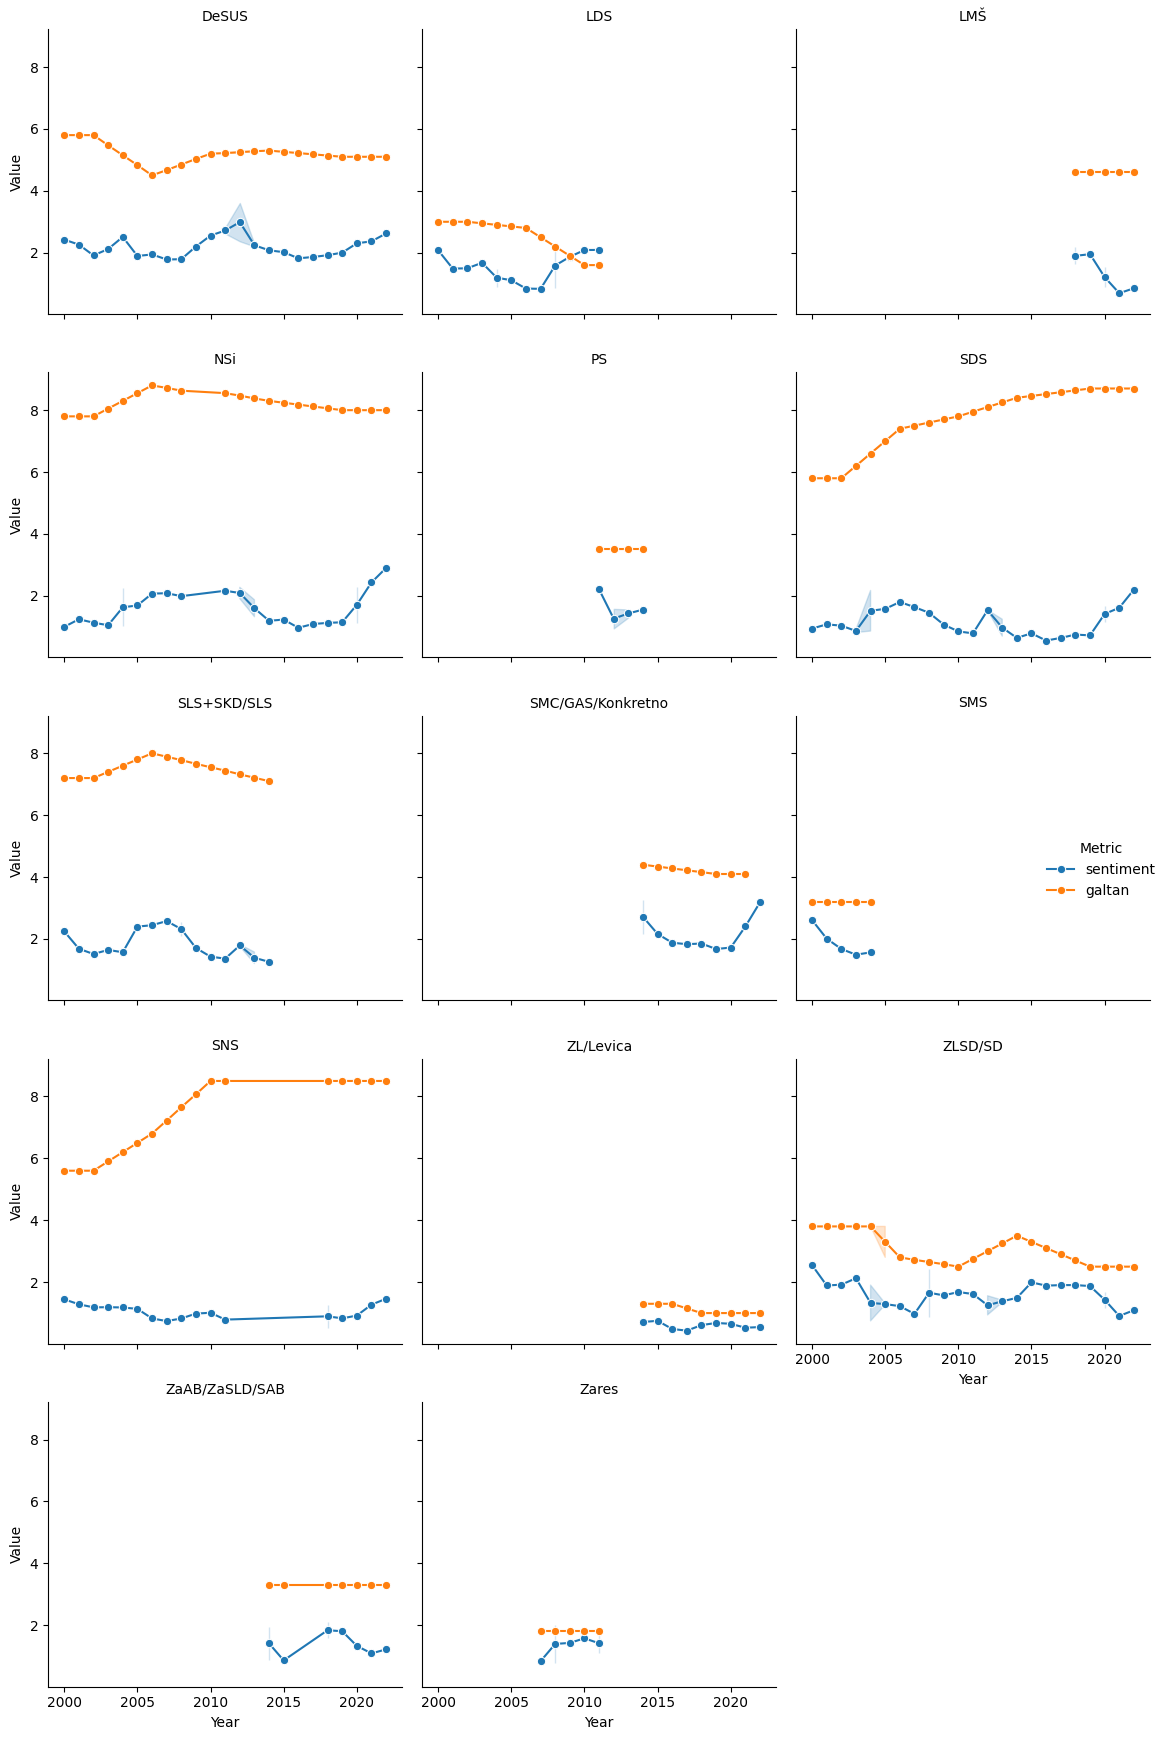

In [25]:
g = sns.FacetGrid(sent_galtan, col="Parties", col_wrap=3, height=3.5, sharey=True, legend_out=True)
g.map_dataframe(sns.lineplot, x="Year", y="Value", hue="Metric",marker="o")

g.add_legend(title="Metric")
g.set_axis_labels("Year", "Value")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

Relationship between sentiment and GALTAN:
The plot visualises relationship between averaged sentiment and GALTAN scores per Year per Party. The lines (or triangles) in sentiment trends denote changes in the party status (e.g. moving from opposition to coalition, or vice versa).
The same relationship, which was observed for LRGEN holds true also for GALTAN/sentiment trends, where (with exception of ZL/Levica), the trends are distinctly different in lrgen/sentiment scores. In addition to Levica, LDS does have some more distinct sentiment trends, where the sentiment rises when their galtan score lowers.